In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Funções de avaliação dos modelos
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV


# visualização da árvore
from sklearn.tree import plot_tree


In [40]:
dataset = pd.read_csv("Datasets/Iris.csv")


In [41]:
X = dataset.drop([dataset.columns[-1]], axis = 1)
y = dataset[dataset.columns[-1]]

In [42]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


## Bagging (Bootstrap aggregation)


Vamos avaliar o $RandomForest$

$RandomForest$ é um meta estimador que ajusta vários classificadores de árvore de decisão em várias subamostras do conjunto de dados e usa a **média** para melhorar a precisão preditiva e controlar o ajuste excessivo.

 O tamanho da subamostra é controlado com o parâmetro $max\_samples$ se $bootstrap=True$ (padrão), caso contrário, todo o conjunto de dados é usado para construir cada árvore.

Alguns parâmetros que vamos ajustar: 

'n_estimators': define o número de árvores. Por padrão 100.

'criterion': função de medida da qualidade do split.  Valores possíveis: {“gini”, “entropy”, “log_loss”}

'max_depth': A profundidade máxima da árvore

Os demais parâmetros estão descritos no seguinte [link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [44]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model = RandomForestClassifier(random_state=42,criterion='entropy')

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(model)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

RandomForestClassifier(criterion='entropy', random_state=42)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



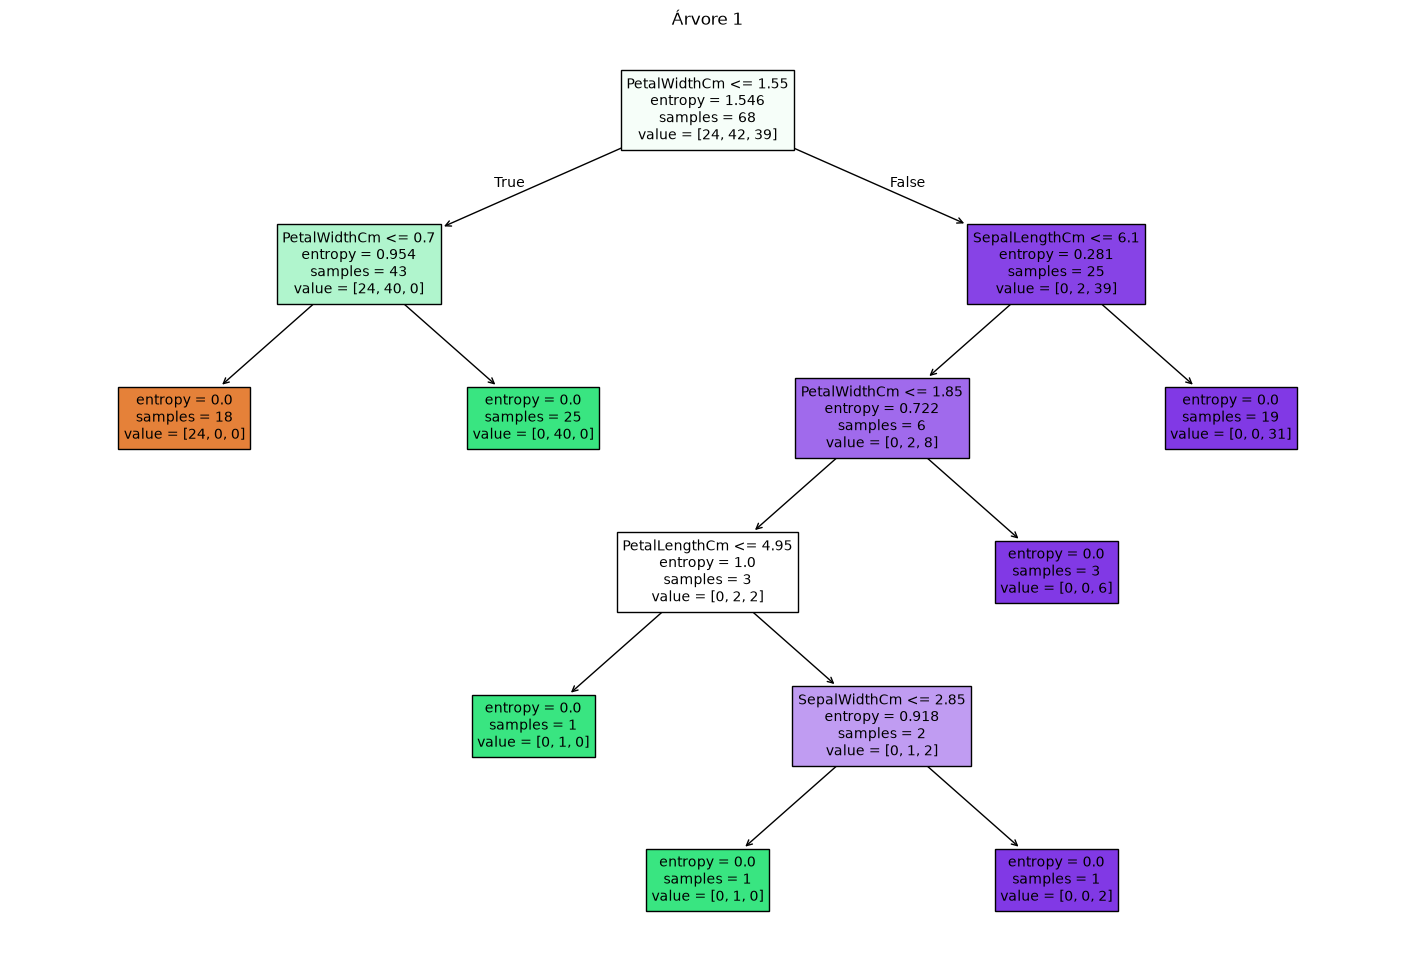

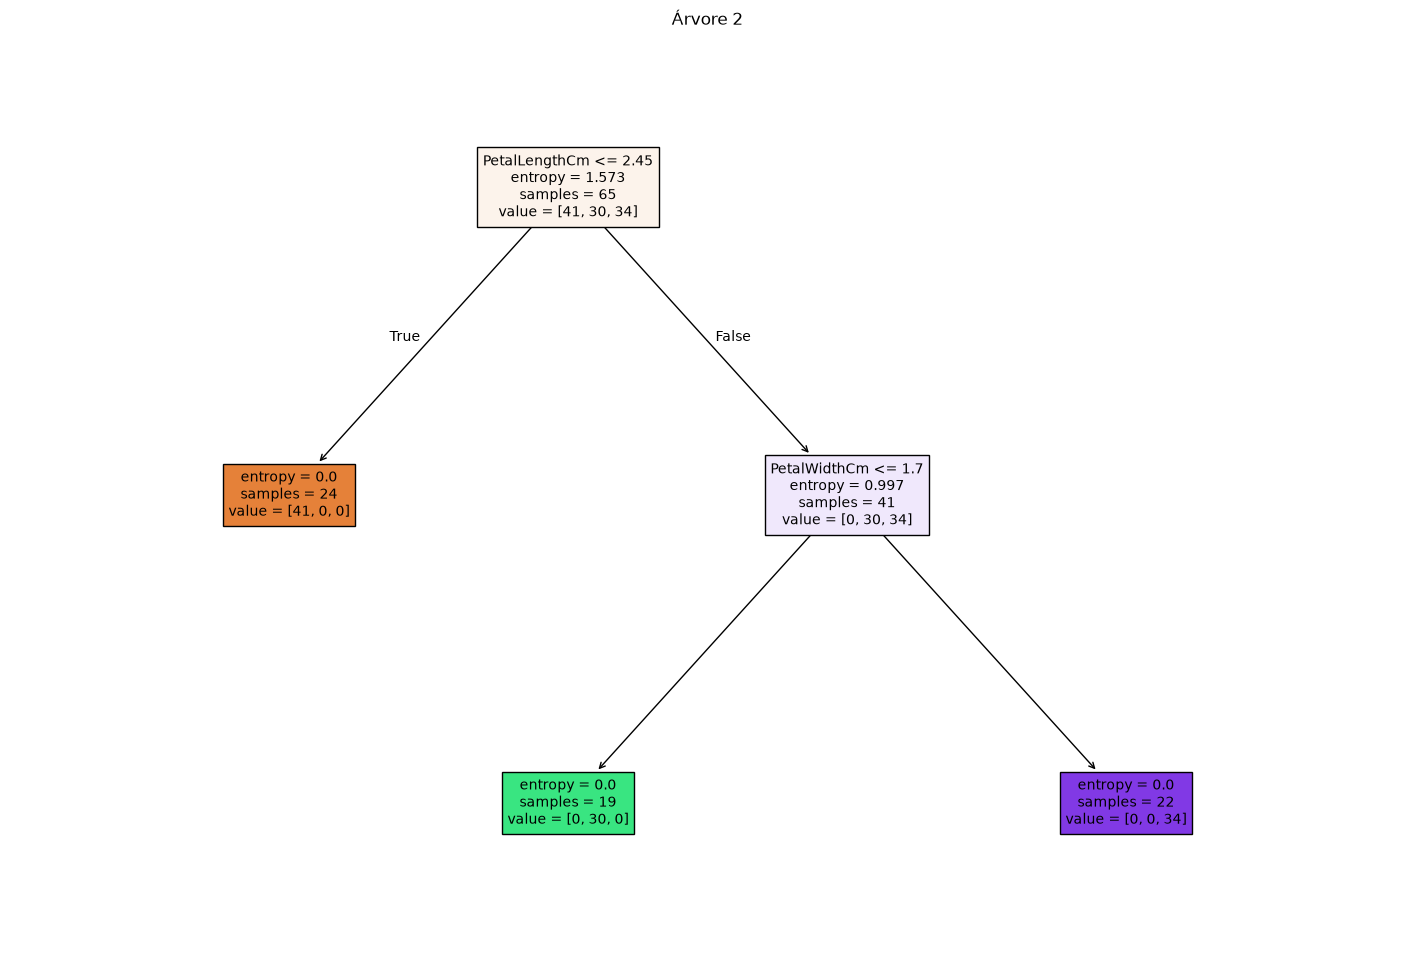

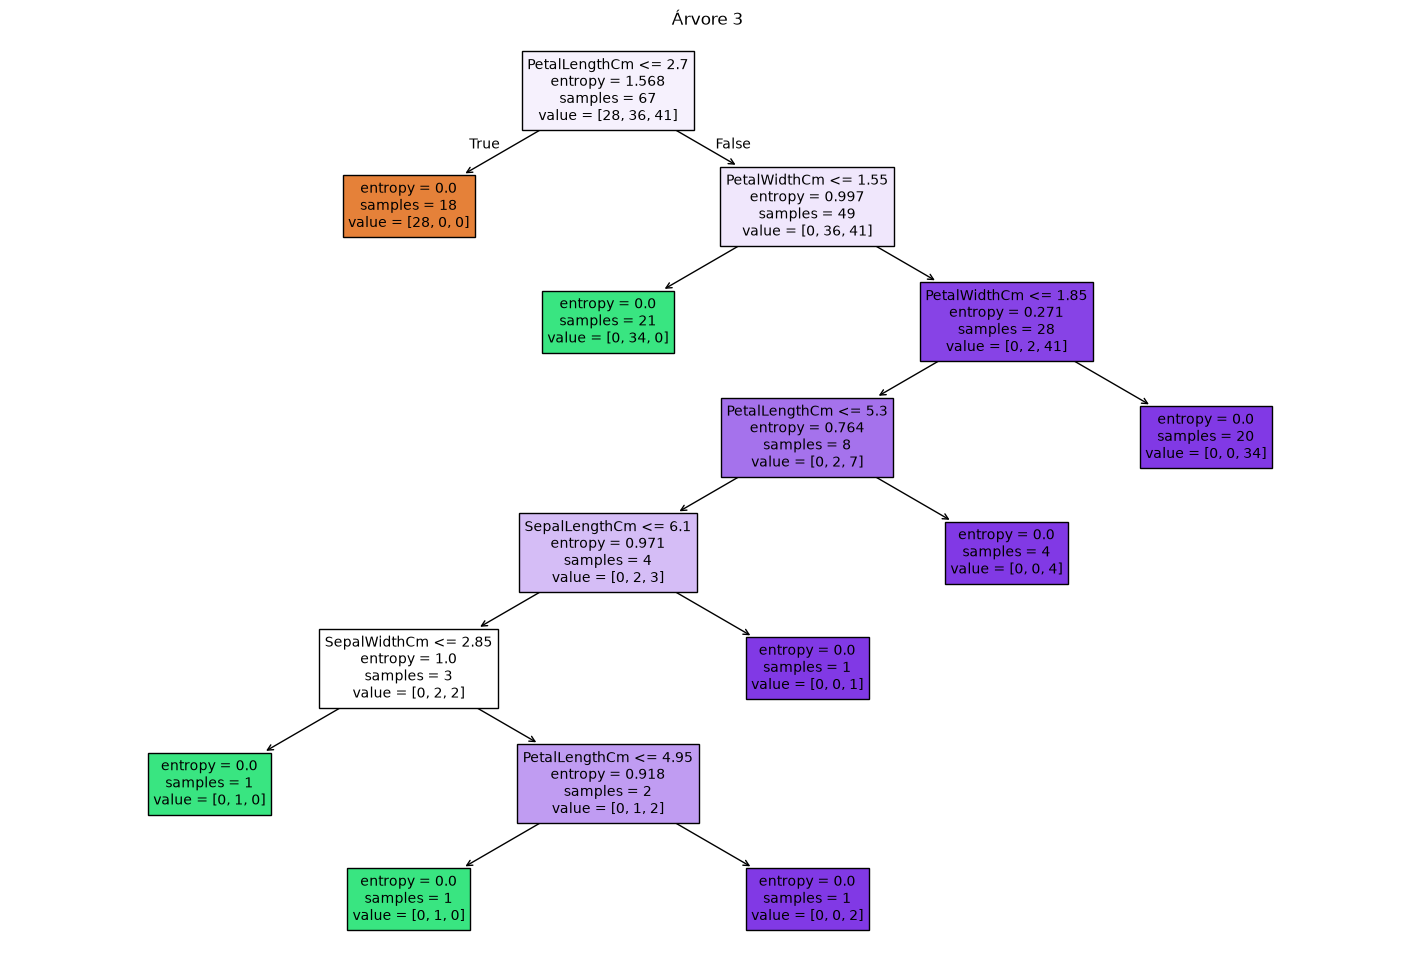

In [46]:
import matplotlib.pyplot as plt

# Visualizar as 3 primeiras árvores
for i in range(3):
    tree = model.estimators_[i]

    plt.figure(figsize=(18, 12))
    plot_tree(tree,feature_names=X_train.columns,filled=True,fontsize=10)
    plt.title(f"Árvore {i + 1}")
    plt.show()

### Ajuste de parâmetros 

In [ ]:
model = RandomForestClassifier(random_state=20)


parameters = {'n_estimators': [50, 100, 150],
              'criterion': ['gini', 'entropy']}

grid = GridSearchCV(estimator = model,             
                    param_grid = parameters,     
                    scoring = 'f1_macro',          # métrica de avaliação
                    cv = 5)                        # cross-validation

grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

print("Melhor parametro:", grid.best_params_)

Melhor parametro: {'criterion': 'gini', 'n_estimators': 50}


In [48]:
#Modelo final com os melhores parâmetros selecionados 
# model = RandomForestClassifier(n_estimators=, criterion=, random_state=20)

print(model)

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

RandomForestClassifier(random_state=20)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## Boosting 

Vamos avaliar dois modelo:

1 - AdaBoost (Adaptive Boosting): é um meta-estimador que começa ajustando um classificador no conjunto de dados original e, em seguida, ajusta cópias adicionais do classificador no mesmo conjunto de dados, mas onde os pesos das instâncias classificadas incorretamente são ajustados de forma que os classificadores subsequentes se concentrem mais em casos difíceis.

2 - XGBoost (Stochastic Gradient Boosting):  algoritmo baseada em Decision Trees (árvores de decisão) com Gradient Boosting (aumento de gradiente).

### Adaboost

In [49]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = AdaBoostClassifier(estimator=None, random_state=20)

#treinando o modelo
model.fit(X_train, y_train)

#Salvando as predições
y_pred = model.predict(X_test)

print("Parâmetros\n")
print(model.get_params())
# Deprecated since version 1.2: base_estimator is deprecated and will be removed in 1.4. Use estimator instead.

print("\nEstimator\n")
print(model.estimator_)

Parâmetros

{'estimator': None, 'learning_rate': 1.0, 'n_estimators': 50, 'random_state': 20}

Estimator

DecisionTreeClassifier(max_depth=1)


**Vamos comparar o desempenho dele com uma árvore de decisão**

In [ ]:
model_dt = DecisionTreeClassifier(max_depth=1, random_state=20)

#treinando o modelo
model_dt = model_dt.fit(X_train, y_train)

#Salvando as predições
y_pred_dt = model_dt.predict(X_test)

Matriz de Confusão sem Adaboost:
Matriz de Confusão com Adaboost:
Acurácia sem Adaboost: 66.67
Acurácia com Adaboost: 93.33


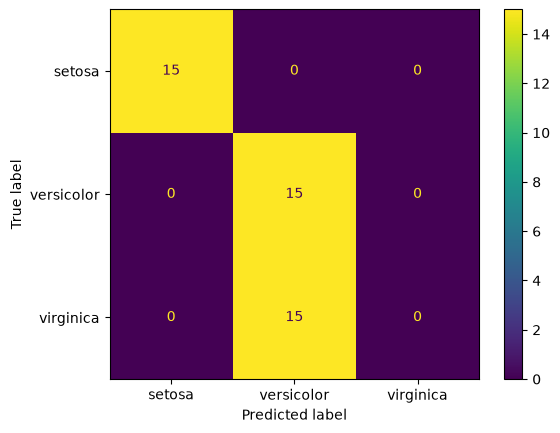

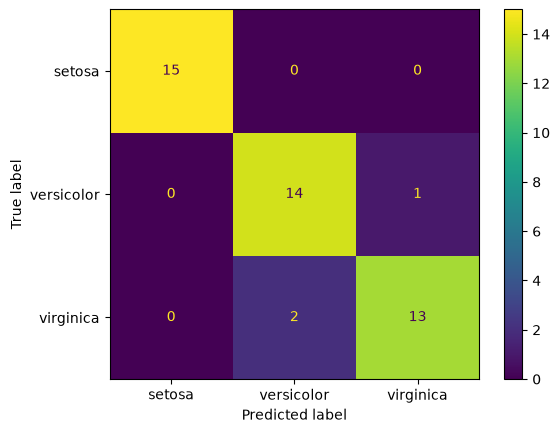

In [52]:
print("Matriz de Confusão sem Adaboost:")
disp_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_dt, labels=model_dt.classes_),
                                 display_labels=model.classes_)
disp_cm.plot()
# print(confusion_matrix(y_test, y_pred_dt))

print("Matriz de Confusão com Adaboost:")
disp_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred, labels=model.classes_),
                                 display_labels=model.classes_)
disp_cm.plot()

print("Acurácia sem Adaboost: %.2f" % (accuracy_score(y_test, y_pred_dt)*100))
print("Acurácia com Adaboost: %.2f" % (accuracy_score(y_test, y_pred)*100))



**Como é possível observar, a adição do Adaboost ao classificador melhora muito sua eficiência.**

**Além disso, abaixo é mostrada a utilização do Adaboost, porém com outro tipo de classificador.**

In [53]:
# Classes do modelo
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
base_estimator = SVC(kernel='linear', probability=True, random_state=20)
# base_estimator = LogisticRegression(random_state=20)

model = CalibratedClassifierCV(SVC(C=10,kernel="rbf"),ensemble=False)

model.fit(X_train, y_train)

#Predict the response for test dataset
y_pred_svm = model.predict(X_test)

print("Acurácia do Adaboost usando outro estimator: %.2f" % (accuracy_score(y_test, y_pred_svm)*100))

Acurácia do Adaboost usando outro estimator: 97.78


AdaBoost foca progressivamente nas amostras que os modelos anteriores erraram. Assim, aumenta o peso das amostras que foram classificadas incorretamente pelos modelos anteriores.

Ou seja, o AdaBoost constrói uma sequência de classificadores SVC e dá mais importância às observações que os classificadores anteriores tiveram dificuldade em classificar.

### XGBoost

XGBoost adiciona árvores para minimizar uma função de perda usando gradientes, com árvores mais sofisticadas e regularização. Documentação [link](https://xgboost.readthedocs.io/en/stable/).


In [54]:
# Instalando a biblioteca
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from xgboost import XGBClassifier
model = XGBClassifier(random_state=20)

print("Parâmetros\n")
print(model.get_params())

Parâmetros

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 20, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [56]:
y_train_ = y_train.map({'versicolor':0,'setosa':1, 'virginica':2})
y_test_ = y_test.map({'versicolor':0,'setosa':1, 'virginica': 2})


In [ ]:
# Problemas de classificação multi-class
model = XGBClassifier(objective="multi:softmax",num_class=3, random_state=20)

#treinando o modelo
model.fit(X_train, y_train_)

#Resultados do classificador
print(classification_report(y_test_, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       1.00      1.00      1.00        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

